# Figure 2 - Multilayer learning: Backprop vs Hebb

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/representation_analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
figure_name = "Fig2_vanBP_bpDale_hebb"
model_list = ["vanBP", "bpDale_learned", "HebbWN_topsup"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Backprop (ANN)
Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)


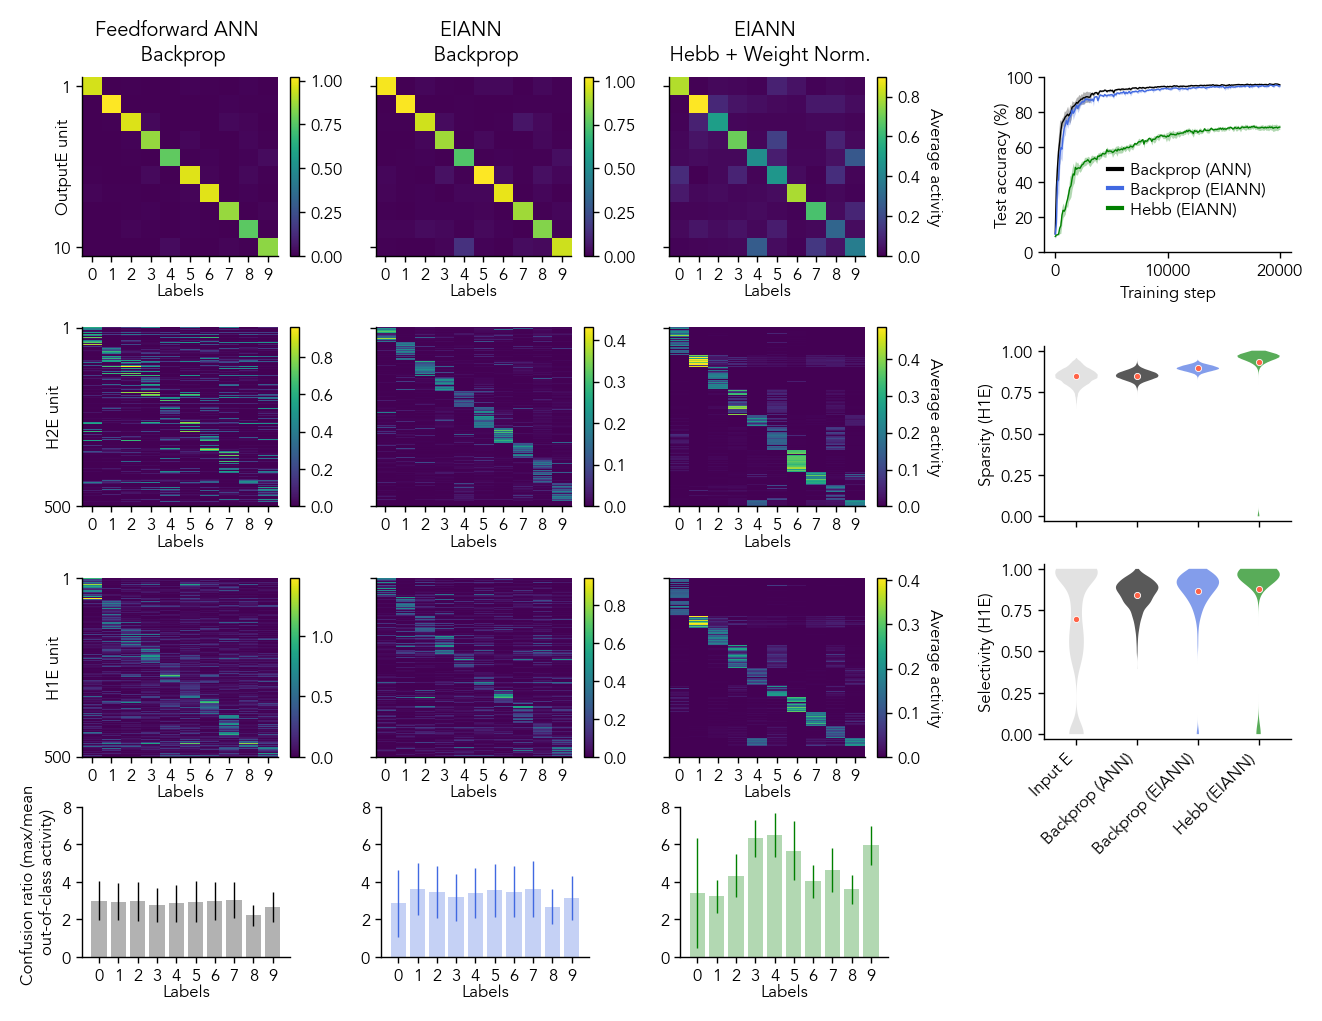

In [ ]:
fig = plt.figure(figsize=(6.5, 5))
axes = gs.GridSpec(nrows=3, ncols=len(model_list), figure=fig,                    
                    left=0.06,right=0.7, top=0.93, bottom=0.25,
                    wspace=0.2, hspace=0.4)

axes_bargraphs = gs.GridSpec(nrows=1, ncols=len(model_list), figure=fig,      
                    left=0.06,right=0.68, top=0.2, bottom=0.05,
                    wspace=0.44, hspace=0.4)

axes_metrics = gs.GridSpec(nrows=5, ncols=1, figure=fig,
                    left=0.8,right=0.99, top=0.93, bottom=0.05,
                    wspace=0.8, hspace=0.3, height_ratios=[1, 0.05, 1, 1, 1])

ax_accuracy    = fig.add_subplot(axes_metrics[0])  
ax_sparsity   = fig.add_subplot(axes_metrics[2])
ax_selectivity = fig.add_subplot(axes_metrics[3])
root_dir = ut.get_project_root()

model_dict_all["vanBP"]["display_name"] = "Feedforward ANN \n Backprop"
model_dict_all["bpDale_learned"]["display_name"] = "EIANN \n Backprop"
model_dict_all["HebbWN_topsup"]["display_name"] = "EIANN \n Hebb + Weight Norm."

for col, model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")

        #########################################################
        # Example heatmaps for E populations
        #########################################################
        example_seed = model_dict['seeds'][0]
        for row, population in enumerate(['OutputE','H2E','H1E']):
            # Activity plots: batch accuracy of each population to the test dataset
            ax = fig.add_subplot(axes[row, col])
            average_pop_activity_dict = data_dict[example_seed]['average_pop_activity_dict']
            num_units = average_pop_activity_dict[population].shape[1]
            pt.plot_batch_accuracy_from_data(average_pop_activity_dict, population=population, sort=True, ax=ax, cbar=True)    
            ax.set_yticks([0,num_units-1])
            ax.set_yticklabels([1,num_units])
            if col == 0:
                ax.set_ylabel(f'{population} unit', labelpad=-7)
            else:
                ax.set_yticklabels([])
                ax.set_ylabel('')
                if col == len(model_list)-1:
                    cbar = ax._colorbars[0]
                    cbar.set_label('Average activity', rotation=270, labelpad=8)        
            if row == 0:
                ax.set_title(model_dict["display_name"])
            ax.set_xlabel(ax.get_xlabel(), labelpad=0)

        #########################################################
        # Class confusion bar graphs
        #########################################################
        population = 'H1E'
        between_class_similarity = {label: [] for label in range(10)}
        between_class_similarity_all = []
        for seed in model_dict['seeds']:
            # Calculate the receptive field similarity for each unit (the histogram will pool data across all model seeds)
            unit_labels_dict = data_dict[seed]['unit_labels_dict']
            unit_labels = unit_labels_dict[population][:]
            idx = np.argsort(unit_labels)
            unit_labels = unit_labels[idx]

            average_pop_activity = np.array(data_dict[seed]['average_pop_activity_dict'][population][:]).T
            sorted_pop_activity = average_pop_activity[idx]

            # Calculate within-class and between-class receptive field similarity (accumulate across all seeds)
            for label in range(10):
                class_idx = np.where(unit_labels == label)[0]
                max_activity_outside_class = np.max(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                mean_activity_outside_class = np.mean(sorted_pop_activity[class_idx][:, np.arange(10)!=label], axis=1)
                confusion_ratio = max_activity_outside_class / (mean_activity_outside_class + 1e-10)
                between_class_similarity_all.extend(confusion_ratio)
                between_class_similarity[label].extend(confusion_ratio)

        # ax = fig.add_subplot(axes[3, col])
        ax = fig.add_subplot(axes_bargraphs[0, col])
        for label in range(10):
            mean_val = np.mean(between_class_similarity[label])
            std_val = np.std(between_class_similarity[label])
            ax.bar(label, mean_val, width=0.8, label='Between-class' if label==0 else None, color=model_dict["color"], alpha=0.3)
            ax.errorbar(label, mean_val, yerr=std_val, fmt='none', ecolor=model_dict["color"], capsize=0, linewidth=0.5)
        if col == 0:
            ax.set_ylabel('Confusion ratio (max/mean \nout-of-class activity)')
        ax.set_xticks(range(10))
        ax.set_xticklabels(range(10))
        ax.set_ylim(0, 8)
        ax.set_xlabel('Labels', labelpad=0)

        ###############
        # Plot metrics
        ###############
        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy, legend=True)

        populations_to_plot = ['H1E', 'H2E']
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_sparsity, metric_name='sparsity', plot_type='violin', side='both')
        plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=populations_to_plot, ax=ax_selectivity, metric_name='selectivity', plot_type='violin', side='both')
        
        ax_sparsity.set_ylabel(f"Sparsity ({' & '.join(populations_to_plot)})")
        ax_selectivity.set_ylabel(f"Selectivity ({' & '.join(populations_to_plot)})")
        ax_sparsity.set_xticklabels([])


        # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E'], ax=ax_sparsity, metric_name='sparsity', plot_type='bar')
        # plot_metric_all_seeds(data_dict, model_dict, populations_to_plot=['H1E'], ax=ax_selectivity, metric_name='selectivity', plot_type='bar')
        # ax_sparsity.set_ylabel('Hidden unit sparsity')
        # ax_sparsity.set_xticklabels([])
        # ax_selectivity.set_ylabel('Hidden unit selectivity')


        # #########################################################
        # # Plot sparsity and selectivity bar charts
        # #########################################################
        # bar_width = 0.5
        # sparsity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
        # selectivity_all_seeds = {'InputE':[], 'H1E':[], 'H2E':[]}
        # for seed in data_dict:
        #     for population in sparsity_all_seeds:
        #         avg_sparsity = np.mean(data_dict[seed][f"metrics_dict"][population]["sparsity"][:])
        #         sparsity_all_seeds[population].append(avg_sparsity)
        #         avg_selectivity = np.mean(data_dict[seed][f"metrics_dict"][population]["selectivity"][:])
        #         selectivity_all_seeds[population].append(avg_selectivity)

        # input_sparsity_data = sparsity_all_seeds['InputE']
        # input_selectivity_data = selectivity_all_seeds['InputE']
        # if col == 0: # Plot InputE bar (same for all models)
        #     ax_sparsity.bar(0, np.mean(input_sparsity_data), color='gray', width=bar_width, alpha=0.5, error_kw={'ecolor': 'black', 'capsize': 3}, yerr= np.std(input_sparsity_data))
        #     ax_selectivity.bar(0, np.mean(input_selectivity_data), color='gray', width=bar_width, alpha=0.5, error_kw={'ecolor': 'black', 'capsize': 3}, yerr= np.std(input_selectivity_data))

        # hidden_sparsity_data = sparsity_all_seeds['H1E'] + sparsity_all_seeds['H2E']
        # hidden_selectivity_data = selectivity_all_seeds['H1E'] + selectivity_all_seeds['H2E']

        # x = len(ax_sparsity.patches)
        # ax_sparsity.bar(x, np.mean(hidden_sparsity_data), yerr=np.std(hidden_sparsity_data), color=model_dict["color"], width=bar_width, alpha=0.5)
        # # ax_sparsity.set_xticks([0, h1e_center, h2e_center])
        # ax_sparsity.set_ylabel('Sparsity')
        # ax_sparsity.set_ylim([0.5, 1])
        # ax_sparsity.tick_params(axis='x', length=0)
        
        # ax_selectivity.bar(x, np.mean(hidden_selectivity_data), yerr=np.std(hidden_selectivity_data), color=model_dict["color"], width=bar_width, alpha=0.5)
        # # ax_selectivity.set_xticks([0, h1e_center, h2e_center])
        # ax_selectivity.set_ylabel('Selectivity')
        # ax_selectivity.set_ylim([0.5, 1])
        # ax_selectivity.tick_params(axis='x', length=0)


fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)

# Supplementary Figure

In [ ]:
figure_name = "Fig2_supplementary"
model_list = ["vanBP", "bpDale_learned", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)